In [93]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [94]:
df = pd.read_csv("wbes_sintetico.csv")
df.head()

,employees,firm_age_years,training,access_finance,exporter,digital_payments,competition_level,sector,sales_annual_usd,labor_productivity_usd_per_employee,successful
0,13.0,10.0,1.0,1.0,0,1,Media,Manufactura,42879.327130,5374.714150,1
1,9.0,6.0,0.0,0.0,0,1,Baja,Servicios,54570.897174,4728.282631,0
2,15.0,10.0,0.0,0.0,1,1,Baja,Servicios,56311.260030,3104.627628,0
3,25.0,12.0,1.0,0.0,1,1,Baja,Servicios,93419.359675,3129.017055,1
4,9.0,9.0,0.0,0.0,0,0,Baja,Manufactura,24608.889361,2824.645056,1


In [95]:
df.replace(" ", np.nan, inplace=True) 
df.dropna(inplace=True)

In [96]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1035 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   employees                            1035 non-null   float64
 1   firm_age_years                       1035 non-null   float64
 2   training                             1035 non-null   float64
 3   access_finance                       1035 non-null   float64
 4   exporter                             1035 non-null   int64  
 5   digital_payments                     1035 non-null   int64  
 6   competition_level                    1035 non-null   object 
 7   sector                               1035 non-null   object 
 8   sales_annual_usd                     1035 non-null   float64
 9   labor_productivity_usd_per_employee  1035 non-null   float64
 10  successful                           1035 non-null   int64  
dtypes: float64(6), int64(3), object(2)


In [97]:
df.dropna()

,employees,firm_age_years,training,access_finance,exporter,digital_payments,competition_level,sector,sales_annual_usd,labor_productivity_usd_per_employee,successful
0,13.0,10.0,1.0,1.0,0,1,Media,Manufactura,42879.327130,5374.714150,1
1,9.0,6.0,0.0,0.0,0,1,Baja,Servicios,54570.897174,4728.282631,0
2,15.0,10.0,0.0,0.0,1,1,Baja,Servicios,56311.260030,3104.627628,0
3,25.0,12.0,1.0,0.0,1,1,Baja,Servicios,93419.359675,3129.017055,1
4,9.0,9.0,0.0,0.0,0,0,Baja,Manufactura,24608.889361,2824.645056,1
...,...,...,...,...,...,...,...,...,...,...,...
1193,12.0,5.0,1.0,0.0,1,1,Media,Servicios,36970.005264,3918.672350,0
1195,13.0,0.0,0.0,0.0,1,0,Media,Servicios,29248.300098,1854.151082,1
1196,10.0,3.0,0.0,0.0,0,0,Baja,Servicios,14581.438242,1133.304438,0
1198,11.0,10.0,0.0,1.0,0,1,Media,Tecnologia,19501.816177,1350.721741,1


In [98]:
# Filtramos para ver empresas con ventas y empleados en rangos normales
df_filtrado = df[(df['sales_annual_usd'] < 50000) & (df['employees'] < 100)]

In [99]:
x = df[["employees"]].values.reshape(-1,1)
y = df[["sales_annual_usd"]].values.reshape(-1,1)

In [100]:
X_train, Y_test, Y_train, X_test = train_test_split(x,y,test_size=0.3,random_state=0)

In [101]:
regressor = LinearRegression()
regressor.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
y_pred = regressor.predict(X_train)

In [103]:
from sklearn.metrics import mean_squared_error, r2_score

print("Coeficiente: \n" , regressor.coef_)
print("Independiente termino: \n " , regressor.intercept_)
print("Mean squared error: %.2f" % mean_squared_error(Y_train, y_pred))

Coeficiente: 
 [[1211.31659367]]
Independiente termino: 
  [15338.43747762]
Mean squared error: 220351584.21


In [104]:
print(regressor.score(X_test,Y_test))
print("Varianza: %.2f" % r2_score(Y_train, y_pred))

-28315105622819.01
Varianza: 0.33


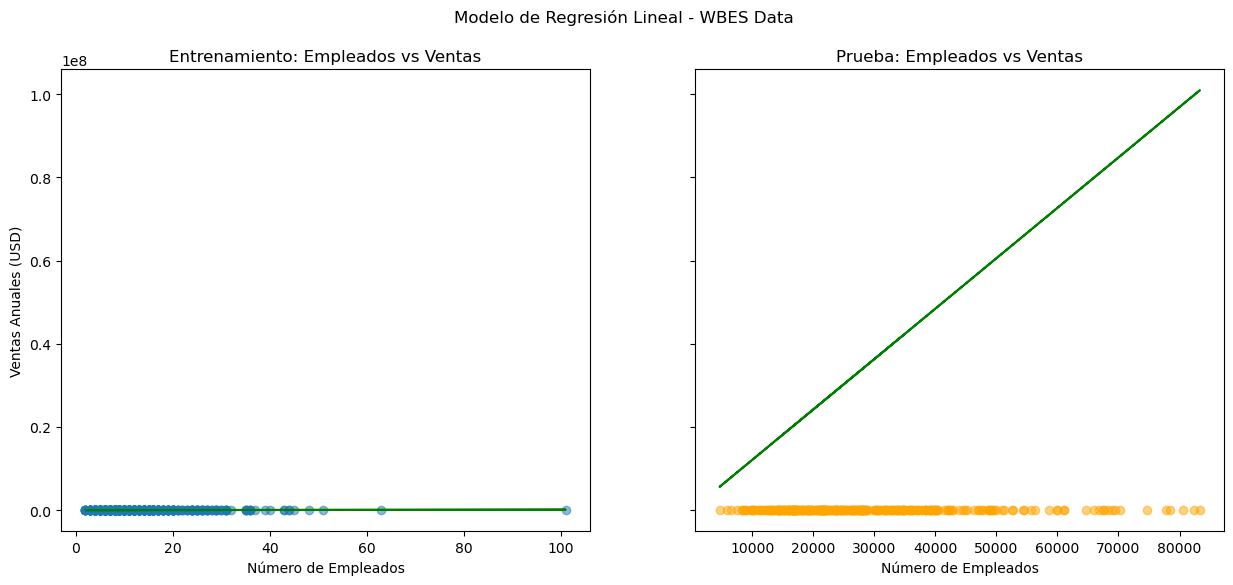

In [105]:
# Definimos los paneles
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Panel 0: Entrenamiento
ax[0].scatter(X_train, Y_train, alpha=0.5) # alpha ayuda si hay muchos puntos
ax[0].plot(X_train, regressor.predict(X_train), c='g')
ax[0].set_title('Entrenamiento: Empleados vs Ventas')
ax[0].set_xlabel('Número de Empleados') # X es la predictora
ax[0].set_ylabel('Ventas Anuales (USD)') # Y es el objetivo

# Panel 1: Prueba (Aquí estaba el detalle)
ax[1].scatter(X_test, Y_test, alpha=0.5, color='orange')
# IMPORTANTE: Usar X_test para la línea en el panel de prueba
ax[1].plot(X_test, regressor.predict(X_test), c='g') 
ax[1].set_title('Prueba: Empleados vs Ventas')
ax[1].set_xlabel('Número de Empleados')
# ax[1].set_ylabel no es necesario por el sharey=True

plt.suptitle('Modelo de Regresión Lineal - WBES Data')
plt.show()

Hemos observado que el número de empleados (variable independiente $X$) tiene una relación positiva con las ventas anuales (variable dependiente $y$). Esto significa que, estadísticamente, a medida que una empresa crece en personal, su capacidad de generación de ingresos tiende a aumentar.